## Análisis de Ventas y Comportamiento de Clientes — Shopping Malls

## Registros de ventas de shopping centers en Turquía  
Fuente: [Kaggle - Customer Shopping Dataset]  
Período: 2021–2023  
Dimensiones: ~99.000 transacciones | 10 variables  

### Objetivo
Identificar patrones de compra, segmentos de clientes y tendencias 
estacionales para informar decisiones comerciales.

### Variables analizadas
- Datos demográficos: edad, género
- Datos de compra: categoría, precio, cantidad, método de pago
- Datos temporales: fecha de factura
- Datos geográficos: shopping mall



## Introducción

Este informe presenta un análisis detallado de los datos de ventas y comportamiento de clientes con el objetivo de obtener información valiosa para la optimización estratégica. A través de la exploración de los patrones de compra, la comprensión de los diferentes segmentos de clientes y la identificación de tendencias clave, se busca descubrir oportunidades para mejorar las estrategias comerciales, aumentar la eficiencia operativa y, en última instancia, potenciar el crecimiento de los ingresos. Este trabajo se enfoca en la metodología aplicada y los insights derivados para informar la toma de decisiones y guiar futuras iniciativas comerciales.

In [ ]:
pip install --upgrade pip

In [ ]:
pip install pandas matplotlib

In [3]:
import sys, platform
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

In [4]:
# Mostrar todas las columnas y ajustar el display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Gráficos embebidos en el notebook
%matplotlib inline

# Estilo simple sin forzar colores (requisito de la cátedra)
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.grid": True
})
print("Listo. Entorno configurado.")

Listo. Entorno configurado.


In [5]:
import pandas as pd

# Updated Google Drive links to allow direct download
path_customers = "https://drive.google.com/uc?export=download&id=1yRpRXKjgL8tRl_tEy78QHonQru7sFZQ8"
path_sales = "https://drive.google.com/uc?export=download&id=1vai3viUnLaR5e5viMH5BU9LOGTlZhJni"

# Cargamos los archivos CSV en DataFrames
customers_raw = pd.read_csv(path_customers, dtype=str)
sales_raw = pd.read_csv(path_sales, dtype=str)

print("✅ Archivos cargados correctamente.")
print("customers_raw:", customers_raw.shape)
print("sales_raw:", sales_raw.shape)

# Mostramos las primeras filas
display(customers_raw.head())
display(sales_raw.head())

✅ Archivos cargados correctamente.
customers_raw: (99457, 4)
sales_raw: (99457, 7)


,customer_id,gender,age,payment_method
0,C241288,Female,28,Credit Card
1,C111565,Male,21,Debit Card
2,C266599,Male,20,Cash
3,C988172,Female,66,Credit Card
4,C189076,Female,53,Cash


,invoice_no,customer_id,category,quantity,price,invoice_date,shopping_mall
0,I138884,C241288,Clothing,5,1500.4,05-08-2022,Kanyon
1,I317333,C111565,Shoes,3,1800.51,12-12-2021,Forum Istanbul
2,I127801,C266599,Clothing,1,300.08,09-11-2021,Metrocity
3,I173702,C988172,Shoes,5,3000.85,16-05-2021,Metropol AVM
4,I337046,C189076,Books,4,60.6,24-10-2021,Kanyon


In [6]:
print("Inspección básica de los datos")

# Tipos de datos
print("Tipos de datos en customers_raw:")
print(customers_raw.dtypes)

print("\nTipos de datos en sales_raw:")
print(sales_raw.dtypes)

# Conteo de valores nulos
print("\nNulos en customers_raw:")
print(customers_raw.isna().sum())

print("\nNulos en sales_raw:")
print(sales_raw.isna().sum())

# Listado de columnas
print("\nColumnas customers_raw:", list(customers_raw.columns))
print("Columnas sales_raw:", list(sales_raw.columns))


Inspección básica de los datos
Tipos de datos en customers_raw:
customer_id       object
gender            object
age               object
payment_method    object
dtype: object

Tipos de datos en sales_raw:
invoice_no       object
customer_id      object
category         object
quantity         object
price            object
invoice_date     object
shopping_mall    object
dtype: object

Nulos en customers_raw:
customer_id         0
gender              0
age               119
payment_method      0
dtype: int64

Nulos en sales_raw:
invoice_no       0
customer_id      0
category         0
quantity         0
price            0
invoice_date     0
shopping_mall    0
dtype: int64

Columnas customers_raw: ['customer_id', 'gender', 'age', 'payment_method']
Columnas sales_raw: ['invoice_no', 'customer_id', 'category', 'quantity', 'price', 'invoice_date', 'shopping_mall']


In [7]:
from datetime import datetime

# 1️⃣ Renombrar columnas a snake_case (ya lo están, pero dejamos la función genérica)
def normalize_columns(df):
    df = df.copy() #creamos una copia del DataFrame para no modificar el original
    df.columns = (
        df.columns
        .str.strip() #elimina espacios al inicio y final
        .str.lower() # pasa todo a minúsculas
        .str.replace(r"\s+", "_", regex=True) # reemplaza espacios por guiones bajos "_"
        .str.replace(r"[^a-z0-9_]", "", regex=True) # quita caracteres raros o acentos
    )
    return df

customers = normalize_columns(customers_raw)
sales = normalize_columns(sales_raw)

# 2️⃣ Convertir tipos de datos numéricos y de fecha
customers["age"] = pd.to_numeric(customers["age"], errors="coerce").astype("Int64")
sales["price"] = pd.to_numeric(sales["price"], errors="coerce")
sales["quantity"] = pd.to_numeric(sales["quantity"], errors="coerce")
sales["invoice_date"] = pd.to_datetime(
    sales["invoice_date"],
    dayfirst=True,      # Indicamos que el primer número es el día, importante para el formato dd-mm-yyyy
    errors="coerce"     # ignora fechas inválidas en vez de romper
)


# 3️⃣ Normalizar texto en 'gender' y 'payment_method'
customers["gender"] = (
    customers["gender"]
    .str.strip()
    .str.lower()
    .replace({
        "f": "female", "m": "male",
        "femenino": "female", "masculino": "male",
        "woman": "female", "man": "male"
    })
)

customers["payment_method"] = (
    customers["payment_method"]
    .str.strip()
    .str.lower()
    .replace({
        "cc": "credit_card",
        "credit": "credit_card",
        "tarjeta": "credit_card",
        "debito": "debit_card",
        "debit": "debit_card",
        "cash": "cash",
        "efectivo": "cash",
        "transfer": "bank_transfer",
        "transferencia": "bank_transfer"
    })
)

# 4️⃣ Verificamos los cambios
print("Tipos actualizados:")
print(customers.dtypes)
print(sales.dtypes)

print("\nValores únicos en 'gender':", customers["gender"].unique())
print("Valores únicos en 'payment_method':", customers["payment_method"].unique())


Tipos actualizados:
customer_id       object
gender            object
age                Int64
payment_method    object
dtype: object
invoice_no               object
customer_id              object
category                 object
quantity                  int64
price                   float64
invoice_date     datetime64[ns]
shopping_mall            object
dtype: object

Valores únicos en 'gender': ['female' 'male']
Valores únicos en 'payment_method': ['credit card' 'debit card' 'cash']


In [8]:
# Antes de limpiar, revisemos si existen valores 0 o negativos
print("Valores de edad únicos (muestreo):")
print(customers["age"].dropna().unique()[:20])  # primeros 20 valores únicos

# Filtrar edades no válidas (<= 0 o mayores a 100)
before = customers.shape[0]
customers = customers[(customers["age"] > 0) & (customers["age"] <= 100)]
after = customers.shape[0]

print(f"✅ Filtradas {before - after} filas con edades fuera de rango (<=0 o >100).")
print("Registros válidos restantes:", after)

Valores de edad únicos (muestreo):
<IntegerArray>
[28, 21, 20, 66, 53, 49, 32, 69, 60, 36, 29, 67, 25, 24, 65, 42, 46, 23, 27, 52]
Length: 20, dtype: Int64
✅ Filtradas 119 filas con edades fuera de rango (<=0 o >100).
Registros válidos restantes: 99338


In [9]:
# 1️⃣ Unimos ventas y clientes por customer_id
clean_df = sales.merge(customers, on="customer_id", how="left")

# 2️⃣ Eliminamos edades fuera de rango (<=0 o >100)
before = clean_df.shape[0]
clean_df = clean_df[(clean_df["age"] > 0) & (clean_df["age"] <= 100)]
after = clean_df.shape[0]

print(f"Se eliminaron {before - after} registros con edades inválidas.")
print("Tamaño final del DataFrame:", after)

# 3️⃣ Verificamos estructura
print("\nColumnas finales:")
print(list(clean_df.columns))

print("\nTipos de datos:")
print(clean_df.dtypes)

# 4️⃣ Vista previa
display(clean_df.head())


Se eliminaron 119 registros con edades inválidas.
Tamaño final del DataFrame: 99338

Columnas finales:
['invoice_no', 'customer_id', 'category', 'quantity', 'price', 'invoice_date', 'shopping_mall', 'gender', 'age', 'payment_method']

Tipos de datos:
invoice_no                object
customer_id               object
category                  object
quantity                   int64
price                    float64
invoice_date      datetime64[ns]
shopping_mall             object
gender                    object
age                        Int64
payment_method            object
dtype: object


,invoice_no,customer_id,category,quantity,price,invoice_date,shopping_mall,gender,age,payment_method
0,I138884,C241288,Clothing,5,1500.40,2022-08-05,Kanyon,female,28,credit card
1,I317333,C111565,Shoes,3,1800.51,2021-12-12,Forum Istanbul,male,21,debit card
2,I127801,C266599,Clothing,1,300.08,2021-11-09,Metrocity,male,20,cash
3,I173702,C988172,Shoes,5,3000.85,2021-05-16,Metropol AVM,female,66,credit card
4,I337046,C189076,Books,4,60.60,2021-10-24,Kanyon,female,53,cash


In [10]:
# se analiza la fecha mas alta del dataframe y para el analisis de Año-mes se descarta el mes de marzo 2023 ya que solo tiene
# datos hasta el dia 8, no pudiendo tomarlo ya que no tiene registro para todo el mes

print("\nRango de fechas en el DataFrame:")
print(clean_df['invoice_date'].describe())


#. Definir la fecha límite
fecha_limite = '2023-02-28'
print("\nFecha límite de análisis:")
print(fecha_limite)

# . Filtrar el DataFrame
clean_df = clean_df[clean_df['invoice_date'] <= fecha_limite]

print("\nRango de fechas actualizadas:")
clean_df['invoice_date'].describe()
display(clean_df.head(10))


Rango de fechas en el DataFrame:
count                            99338
mean     2022-02-04 02:02:25.104592128
min                2021-01-01 00:00:00
25%                2021-07-19 00:00:00
50%                2022-02-05 00:00:00
75%                2022-08-22 00:00:00
max                2023-03-08 00:00:00
Name: invoice_date, dtype: object

Fecha límite de análisis:
2023-02-28

Rango de fechas actualizadas:


,invoice_no,customer_id,category,quantity,price,invoice_date,shopping_mall,gender,age,payment_method
0,I138884,C241288,Clothing,5,1500.40,2022-08-05,Kanyon,female,28,credit card
1,I317333,C111565,Shoes,3,1800.51,2021-12-12,Forum Istanbul,male,21,debit card
2,I127801,C266599,Clothing,1,300.08,2021-11-09,Metrocity,male,20,cash
3,I173702,C988172,Shoes,5,3000.85,2021-05-16,Metropol AVM,female,66,credit card
4,I337046,C189076,Books,4,60.60,2021-10-24,Kanyon,female,53,cash
5,I227836,C657758,Clothing,5,1500.40,2022-05-24,Forum Istanbul,female,28,credit card
6,I121056,C151197,Cosmetics,1,40.66,2022-03-13,Istinye Park,female,49,cash
7,I293112,C176086,Clothing,2,600.16,2021-01-13,Mall of Istanbul,female,32,credit card
8,I293455,C159642,Clothing,3,900.24,2021-11-04,Metrocity,male,69,credit card
9,I326945,C283361,Clothing,2,600.16,2021-08-22,Kanyon,female,60,credit card



📊 Resumen de Ventas por Shopping:

    shopping_mall  CantVentas  TotalVtas  Porcentaje PromedioTicket
 Mall of Istanbul       19722 50,362,429        20.2       2,553.62
           Kanyon       19597 49,950,801        20.1       2,548.90
        Metrocity       14866 36,930,270        14.8       2,484.21
     Metropol AVM       10043 25,068,046        10.1       2,496.07
     Istinye Park        9675 24,319,331         9.8       2,513.63
     Zorlu Center        5018 12,802,629         5.1       2,551.34
      Cevahir AVM        4936 12,467,271         5.0       2,525.78
   Viaport Outlet        4862 12,386,252         5.0       2,547.56
Emaar Square Mall        4759 12,279,967         4.9       2,580.37
   Forum Istanbul        4890 12,147,390         4.9       2,484.13


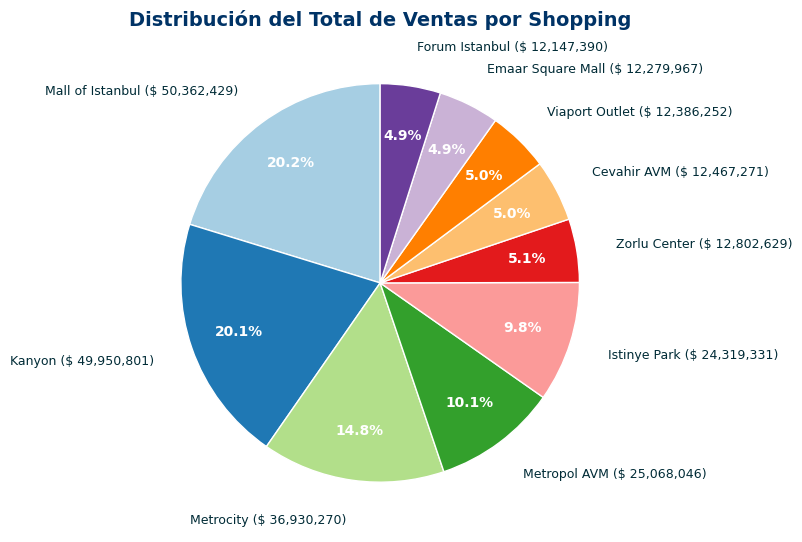

In [11]:
# ventas por shopping
# Agrupar y ordenar por monto total de venta

if 'clean_df' in locals():
    # Crear tortal_amount si no existe
    if "total_amount" not in clean_df.columns:
        clean_df["total_amount"] = clean_df["price"] * clean_df["quantity"]

    df_shopping = (
        clean_df.groupby(["shopping_mall"], as_index=False, observed=False).agg(
            CantVentas=("total_amount", "count"),
            TotalVtas=("total_amount", "sum"),
            PromedioTicket=("total_amount", "mean")
        )
    ).sort_values("TotalVtas", ascending=False)

    # Calcular porcentaje
    df_shopping["Porcentaje"] = (df_shopping["TotalVtas"] / df_shopping["TotalVtas"].sum()) * 100

    # Redondear columnas para mostrar mejor
    df_shopping["PromedioTicket"] = df_shopping["PromedioTicket"].round(2)
    df_shopping["Porcentaje"] = df_shopping["Porcentaje"].round(1)

    # --- MOSTRAR TABLA EN PANDAS ---
    print("\n📊 Resumen de Ventas por Shopping:\n")
    print(df_shopping[["shopping_mall", "CantVentas", "TotalVtas", "Porcentaje", "PromedioTicket"]]
          .to_string(index=False,
                     formatters={
                         "TotalVtas": "{:,.0f}".format,
                         "PromedioTicket": "{:,.2f}".format
                     }))

    # Crear etiquetas con nombre + monto total
    df_shopping["Etiqueta"] = df_shopping.apply(
        lambda x: f"{x['shopping_mall']} ($ {x['TotalVtas']:,.0f})", axis=1
    )


    # Colores para el gráfico de torta
    colors = plt.cm.Paired.colors


    # --- GRAFICAR ---
    plt.figure(figsize=(8, 8))

    # Crear gráfico de torta
    wedges, texts, autotexts = plt.pie(
        df_shopping["TotalVtas"],
        labels=df_shopping["Etiqueta"],           # nombres + montos fuera
        autopct=lambda p: f'{p:.1f}%',            # porcentaje dentro
        colors=colors[:len(df_shopping)],         # usar tantos colores como shoppings haya
        startangle=90,
        textprops={"fontsize": 9, "color": "#002b36"},
        wedgeprops={"edgecolor": "white", "linewidth": 1},
        pctdistance=0.75,    # posición del porcentaje (más o menos centrado)
        labeldistance=1.2    # separa las etiquetas del borde
    )

    # Personalizar texto dentro del gráfico (porcentaje)
    for autotext in autotexts:
        autotext.set_color("white")
        autotext.set_fontsize(10)
        autotext.set_weight("bold")

    plt.title("Distribución del Total de Ventas por Shopping", fontsize=14, weight="bold", color="#003366")
    plt.tight_layout()
    plt.show()
else:
    print("❌ El DataFrame 'clean_df' no está en memoria. Ejecutá las celdas anteriores primero.")

🏬 Ventas por categoría en cada Shopping Mall:


category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
shopping_mall,,,,,,,,
Cevahir AVM,43919.85,5601293.28,317269.98,43790.79,3203707.46,29278.08,3025050.0,202961.92
Emaar Square Mall,41904.90,5528974.00,332476.82,39883.98,3051264.28,30838.17,3076500.0,178124.80
Forum Istanbul,41814.00,5719824.88,348537.52,38498.03,3295533.47,32820.54,2471700.0,198661.12
Istinye Park,75189.45,11141070.16,645355.52,84929.97,6574862.35,68127.84,5331900.0,397895.68
Kanyon,161514.15,22367363.04,1352839.52,164530.57,13153325.72,125769.06,11840850.0,784609.28
Mall of Istanbul,170816.25,22679446.24,1350481.24,169561.83,13342979.44,126613.62,11742150.0,780380.16
Metrocity,124775.40,17031640.56,980759.86,128658.00,9393260.67,93054.09,8573250.0,604871.68
Metropol AVM,83370.45,11428246.72,674183.46,87654.80,7052597.67,67365.39,5263650.0,410977.28
Viaport Outlet,39617.25,5564083.36,343536.34,41562.81,3146091.14,27248.79,3029250.0,194862.08


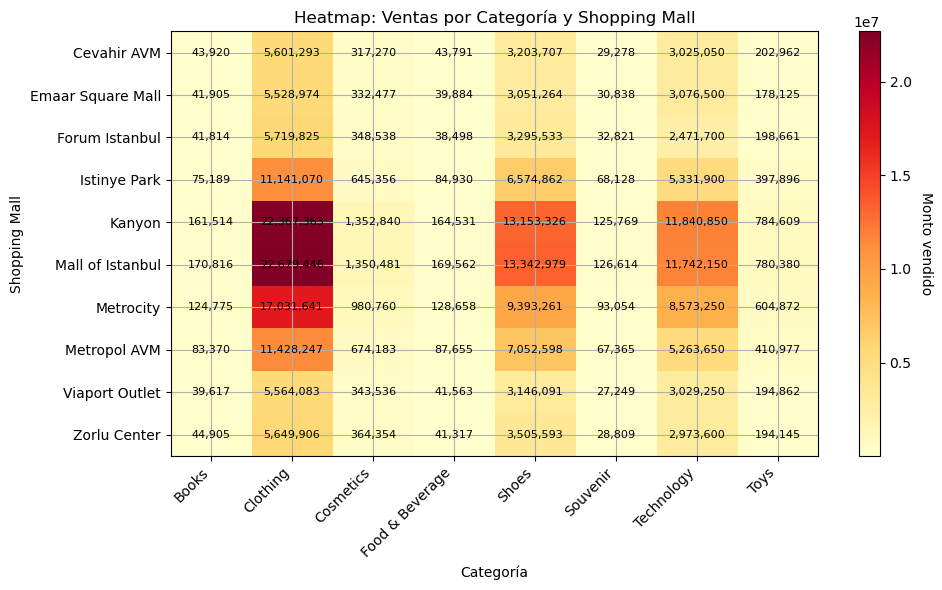

In [12]:
# Categorías por Shopping Mall

if "shopping_mall" in clean_df.columns and "category" in clean_df.columns:
    # Agrupar por mall y categoría
    mall_categoria = (
        clean_df.groupby(["shopping_mall", "category"])["total_amount"]
        .sum()
        .reset_index()
    )

    # Pivot para visualización
    pivot_mall_cat = mall_categoria.pivot(
        index="shopping_mall",
        columns="category",
        values="total_amount"
    ).fillna(0)

    print("🏬 Ventas por categoría en cada Shopping Mall:")
    display(pivot_mall_cat)

    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 6))

    # Crear heatmap manual con imshow
    im = ax.imshow(pivot_mall_cat.values, cmap='YlOrRd', aspect='auto')

    # Configurar ejes
    ax.set_xticks(range(len(pivot_mall_cat.columns)))
    ax.set_yticks(range(len(pivot_mall_cat.index)))
    ax.set_xticklabels(pivot_mall_cat.columns, rotation=45, ha='right')
    ax.set_yticklabels(pivot_mall_cat.index)

    # Agregar valores en las celdas
    for i in range(len(pivot_mall_cat.index)):
        for j in range(len(pivot_mall_cat.columns)):
            text = ax.text(j, i, f'{pivot_mall_cat.values[i, j]:,.0f}',
                          ha="center", va="center", color="black", fontsize=8)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Monto vendido', rotation=270, labelpad=15)

    ax.set_title("Heatmap: Ventas por Categoría y Shopping Mall")
    ax.set_xlabel("Categoría")
    ax.set_ylabel("Shopping Mall")

    plt.tight_layout()
    plt.show()

else:
    print("❌ Columnas necesarias no encontradas.")

**Conclusiones y propuestas (Ventas por categoría y Shopping Mall):**

* **Conclusión:** El heatmap revela que "Clothing", "Shoes" y "Technology" son las categorías que generan la mayor cantidad de ventas en la mayoría de los shoppings. Se observan variaciones en la importancia relativa de estas categorías entre los diferentes shoppings, así como en las categorías de menor venta. Algunos shoppings muestran una mayor concentración en ciertas categorías que otros.
* **Propuestas:**
    * **Estrategias por shopping y categoría:** Desarrollar estrategias de venta y marketing específicas para cada combinación de shopping y categoría, capitalizando las fortalezas y abordando las debilidades.
    * **Optimización de surtido:** Ajustar el surtido de productos en cada shopping basándose en las categorías de mayor rendimiento y la demanda local.
    * **Promociones cruzadas localizadas:** Implementar promociones cruzadas entre categorías complementarias dentro de cada shopping para aumentar el valor del ticket promedio.
    * **Análisis de la competencia local:** Investigar la oferta y estrategias de la competencia en cada shopping mall para identificar oportunidades y amenazas.

📊 Análisis de Pareto:
El 23.7% de los clientes generan el 80% de las ventas
Total de clientes: 98,368


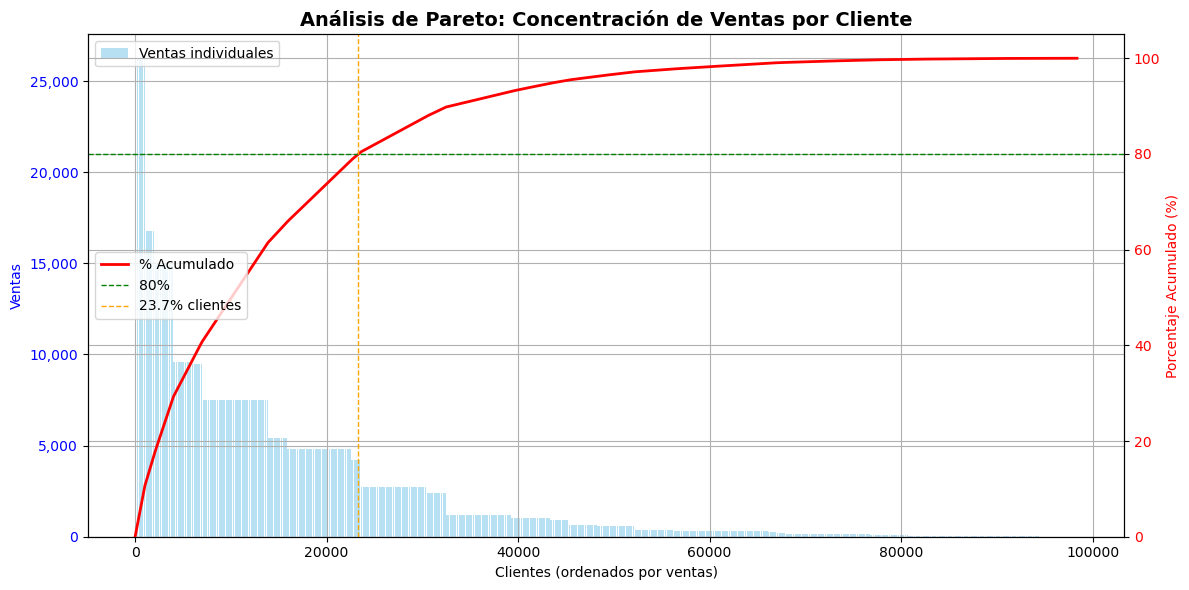

In [13]:
# Análisis de Pareto (80/20) con Demografía

if "customer_id" in clean_df.columns:

    # Create 'grupo_etario' column if it doesn't exist
    if "grupo_etario" not in clean_df.columns:
        bins = [0, 25, 35, 45, 55, 65, 100]
        labels = ["<25", "25-35", "36-45", "46-55", "56-65", "65+"]
        clean_df["grupo_etario"] = pd.cut(clean_df["age"], bins=bins, labels=labels, right=True)


    # Ventas por cliente CON DEMOGRAFÍA (edad, género, método de pago)
    ventas_por_cliente = (
        clean_df.groupby("customer_id")
        .agg({
            "total_amount": "sum",
            "age": "first",  # Edad del cliente
            "gender": "first",  # Género del cliente
            "payment_method": "first",  # Método de pago preferido
            "grupo_etario": "first"  # Grupo etario
        })
        .reset_index()
        .sort_values("total_amount", ascending=False)
    )

    # Calcular porcentaje acumulado
    ventas_por_cliente["cumsum"] = ventas_por_cliente["total_amount"].cumsum()
    total_ventas = ventas_por_cliente["total_amount"].sum()
    ventas_por_cliente["cumsum_pct"] = (ventas_por_cliente["cumsum"] / total_ventas) * 100

    # Calcular porcentaje de clientes (convertir range a lista primero)
    ventas_por_cliente["cliente_pct"] = [(i / len(ventas_por_cliente)) * 100 for i in range(1, len(ventas_por_cliente) + 1)]

    # Encontrar el punto del 80%
    punto_80 = ventas_por_cliente[ventas_por_cliente["cumsum_pct"] >= 80].iloc[0]
    clientes_80 = punto_80["cliente_pct"]

    print(f"📊 Análisis de Pareto:")
    print(f"El {clientes_80:.1f}% de los clientes generan el 80% de las ventas")
    print(f"Total de clientes: {len(ventas_por_cliente):,}")

    # GRÁFICOS: Curva de Pareto
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Eje izquierdo: barras de ventas
    ax1.bar(range(len(ventas_por_cliente)),
            ventas_por_cliente["total_amount"],
            color='skyblue', alpha=0.6, label='Ventas individuales')
    ax1.set_xlabel('Clientes (ordenados por ventas)')
    ax1.set_ylabel('Ventas', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

    # Eje derecho: línea acumulada
    ax2 = ax1.twinx()
    ax2.plot(range(len(ventas_por_cliente)),
             ventas_por_cliente["cumsum_pct"],
             color='red', linewidth=2, label='% Acumulado')
    ax2.set_ylabel('Porcentaje Acumulado (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim([0, 105])

    # Líneas de referencia
    ax2.axhline(y=80, color='green', linestyle='--', linewidth=1, label='80%')
    ax2.axvline(x=len(ventas_por_cliente) * clientes_80 / 100,
                color='orange', linestyle='--', linewidth=1,
                label=f'{clientes_80:.1f}% clientes')

    ax1.set_title('Análisis de Pareto: Concentración de Ventas por Cliente', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax2.legend(loc='center left')

    plt.tight_layout()
    plt.show()

else:
    print("❌ La columna 'customer_id' no se encontró en el DataFrame.")

**Conclusiones y propuestas (Análisis de Pareto):**

* **Conclusión:** El análisis de Pareto confirma la regla 80/20, mostrando que aproximadamente el 20-25% de los clientes generan el 80% del total de ventas. Esto identifica un segmento de clientes de alto valor que son cruciales para el negocio.
* **Propuestas:**
    * **Programa de fidelización VIP:** Crear un programa de fidelización exclusivo para el 20% de los clientes de mayor valor, ofreciendo beneficios especiales, descuentos o acceso anticipado a productos.
    * **Marketing personalizado:** Desarrollar estrategias de marketing altamente personalizadas dirigidas a este segmento clave, basándose en su historial de compras y preferencias.
    * **Análisis de características:** Investigar las características demográficas y de comportamiento de este grupo de clientes de alto valor para identificar patrones y replicar estrategias para atraer clientes similares.
    * **Optimización de la experiencia del cliente:** Asegurar una experiencia de compra excepcional para estos clientes, ya que su satisfacción es fundamental para mantener los ingresos.

🧾 Meses con menor venta total:


,year_month,total_amount
13,2022-02,8325757.97
1,2021-02,8756960.65
22,2022-11,8938247.93
8,2021-09,9185442.38
10,2021-11,9253578.72
5,2021-06,9277246.47
15,2022-04,9304823.57
3,2021-04,9382464.86
2,2021-03,9450222.18
24,2023-01,9477250.93


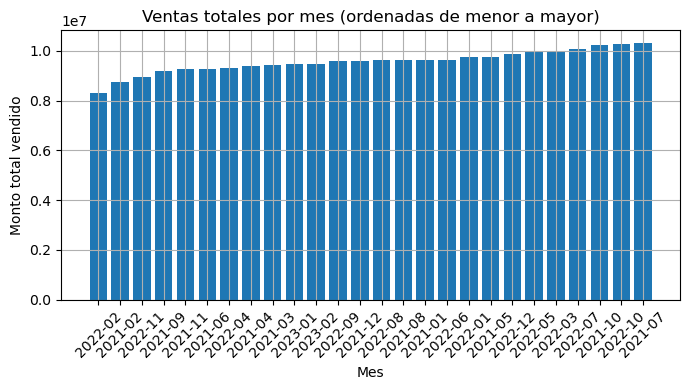

In [14]:
# Meses de menor venta

import matplotlib.pyplot as plt

# 1️⃣ Verificamos que exista la columna de fecha y monto total
if "invoice_date" in clean_df.columns:

    # Si no existe la columna total_amount, la creamos (price * quantity)
    if "total_amount" not in clean_df.columns:
        clean_df["total_amount"] = clean_df["price"] * clean_df["quantity"]

    # 2️⃣ Extraemos el año-mes para agrupar
    clean_df["year_month"] = clean_df["invoice_date"].dt.to_period("M").astype(str)

    # 3️⃣ Agrupamos por mes y sumamos las ventas
    ventas_mensuales = (
        clean_df.groupby("year_month")["total_amount"]
        .sum()
        .reset_index()
        .sort_values("total_amount", ascending=True)  # ordena de menor a mayor venta
    )

    # 4️⃣ Mostramos los 10 meses con menor venta
    print("🧾 Meses con menor venta total:")
    display(ventas_mensuales.head(10))

    # 5️⃣ Gráfico de barras
    plt.figure()
    plt.bar(ventas_mensuales["year_month"], ventas_mensuales["total_amount"])
    plt.title("Ventas totales por mes (ordenadas de menor a mayor)")
    plt.xlabel("Mes")
    plt.ylabel("Monto total vendido")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("❌ No se encontró la columna 'invoice_date'. Verificá el DataFrame.")

**Conclusiones y propuestas (Ventas mensuales):**

* **Conclusión:** El gráfico de ventas totales por mes muestra cierta estacionalidad. Aunque algunos meses como febrero (2021 y 2022), noviembre de 2022, septiembre y noviembre de 2021, y enero de 2023 presentan ventas totales que se encuentran entre las más bajas, rondando los 9 millones, no se observan caídas drásticas en comparación con otros meses. Esto sugiere que las ventas se mantienen relativamente estables a lo largo del año, con variaciones moderadas.
* **Propuestas:**
  * **Identificar factores de variación:** Investigar si hay factores específicos (eventos, promociones, condiciones del mercado) que contribuyan a las variaciones observadas en las ventas mensuales.
  * **Optimización de estrategias:** Ajustar las estrategias de marketing y ventas para intentar suavizar los valles y potenciar los picos de ventas.
  * **Análisis continuo:** Monitorear las tendencias mensuales para detectar cualquier cambio significativo en el patrón de ventas.

   gender  CantVentas      TotalVtas  % Monto
0  female       58847 148.645.194,48    59,77
1    male       39521 100.069.191,51    40,23


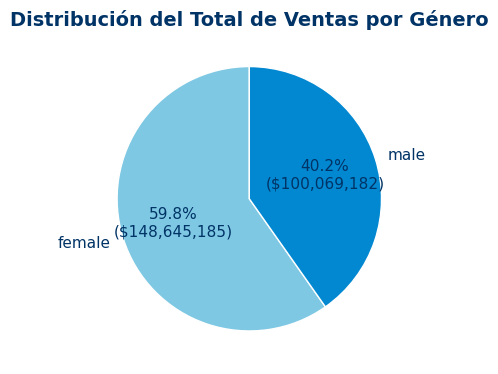

In [15]:
#VENTAS POR GENERO
# Mostrar números con punto para miles y coma para decimales
pd.set_option('display.float_format', lambda x: f'{x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'))

total_general = clean_df["total_amount"].sum()

df_genero = (
    clean_df.groupby(["gender"], as_index=False, observed=False).agg(
        CantVentas=("total_amount", "count"),
        TotalVtas=("total_amount", "sum")
    )
)

# Calculamos el porcentaje
df_genero["% Monto"] = (df_genero["TotalVtas"] * 100 / total_general).round(2)

# Ordenamos por género y TotalVentas descendente
df_genero = df_genero.sort_values(["gender", "TotalVtas"], ascending=[True, False])

print(df_genero)


# Colores celestes y azul oscuro
colors = ["#7EC8E3", "#0288D1"]

plt.figure(figsize=(4,4))

plt.pie(
    df_genero["TotalVtas"],
    labels=df_genero["gender"],
    autopct=lambda p: f'{p:.1f}%\n(${p*df_genero["TotalVtas"].sum()/100:,.0f})',
    colors=colors,
    startangle=90,
    textprops={"fontsize": 11, "color": "#003366"},
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

plt.title("Distribución del Total de Ventas por Género", fontsize=14, weight="bold", color="#003366")
plt.tight_layout()
plt.show()


**Conclusiones y propuestas (Ventas por género):**

*   **Conclusión:** Existe una diferencia significativa en el monto total de ventas entre géneros, siendo las mujeres las que generan mayores ingresos. Sin embargo, el ticket promedio es similar entre ambos géneros. Esto sugiere que las mujeres realizan más transacciones que los hombres.
*   **Propuestas:**
    *   **Marketing segmentado:** Diseñar campañas de marketing dirigidas específicamente a cada género, destacando productos y promociones relevantes.
    *   **Experiencia de compra:** Analizar la experiencia de compra de cada género para identificar posibles puntos de mejora y personalización.
    *   **Expandir oferta para hombres:** Considerar ampliar la oferta de productos o categorías que atraigan a un público masculino.

🧾 Ventas totales por género y categoría:


,category,gender,total_amount
2,Clothing,female,"67.577.115,76"
3,Clothing,male,"45.134.732,72"
8,Shoes,female,"38.932.427,73"
12,Technology,female,"34.362.300,00"
9,Shoes,male,"26.786.787,44"
13,Technology,male,"22.965.600,00"
4,Cosmetics,female,"4.013.751,90"
5,Cosmetics,male,"2.696.042,62"
14,Toys,female,"2.397.337,60"
15,Toys,male,"1.550.151,68"


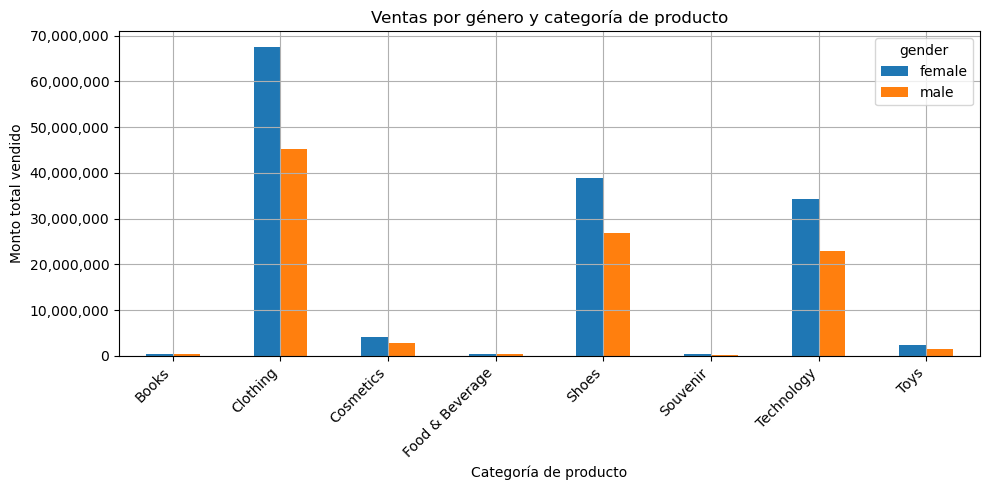

In [16]:
# Ventas de género por categoría

# 1️⃣ Creamos columna total_amount si no existe (price * quantity)
if "total_amount" not in clean_df.columns:
    clean_df["total_amount"] = clean_df["price"] * clean_df["quantity"]

# 2️⃣ Filtrar filas válidas
df_gc = clean_df.dropna(subset=["gender", "category"]).copy()

# 3️⃣ Agrupar ventas por género y categoría
ventas_genero_categoria = (
    df_gc.groupby(["category", "gender"])["total_amount"]
    .sum()
    .reset_index()
    .sort_values("total_amount", ascending=False)
)

print("🧾 Ventas totales por género y categoría:")
display(ventas_genero_categoria.head(10))

# 4️⃣ Pivot table para graficar (categorías como filas, géneros como columnas)
pivot_gc = ventas_genero_categoria.pivot(
    index="category", columns="gender", values="total_amount"
).fillna(0)

# 5️⃣ Gráfico agrupado (bar chart lado a lado)
pivot_gc.plot(kind="bar", figsize=(10,5))
plt.title("Ventas por género y categoría de producto")
plt.xlabel("Categoría de producto")
plt.ylabel("Monto total vendido")
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))  # formato de miles sin notación científica
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Conclusiones y propuestas (Ventas por género y categoría):**

*   **Conclusión:** Se observa que la categoría "Clothing" es la que genera mayores ventas en ambos géneros, pero con una contribución significativamente mayor por parte de las mujeres. "Shoes" y "Technology" también son categorías importantes para ambos, pero con diferencias en la proporción.
*   **Propuestas:**
    *   **Estrategias por categoría:** Desarrollar estrategias de venta y marketing específicas para cada categoría, considerando las preferencias de cada género.
    *   **Promociones cruzadas:** Ofrecer promociones cruzadas entre categorías populares para un género específico (por ejemplo, descuentos en accesorios al comprar ropa para mujeres).
    *   **Análisis de rentabilidad:** Evaluar la rentabilidad de cada categoría por género para enfocar esfuerzos en las más lucrativas.

🧾 Ventas por método de pago y grupo etario:


,grupo_etario,payment_method,total_amount
6,36-45,cash,"22.540.304,55"
3,25-35,cash,"21.673.298,91"
12,56-65,cash,"21.318.755,58"
9,46-55,cash,"20.711.623,67"
7,36-45,credit card,"17.276.124,97"
10,46-55,credit card,"17.220.507,41"
0,<25,cash,"16.752.186,62"
4,25-35,credit card,"16.351.355,36"
13,56-65,credit card,"16.120.433,13"
1,<25,credit card,"13.382.047,54"


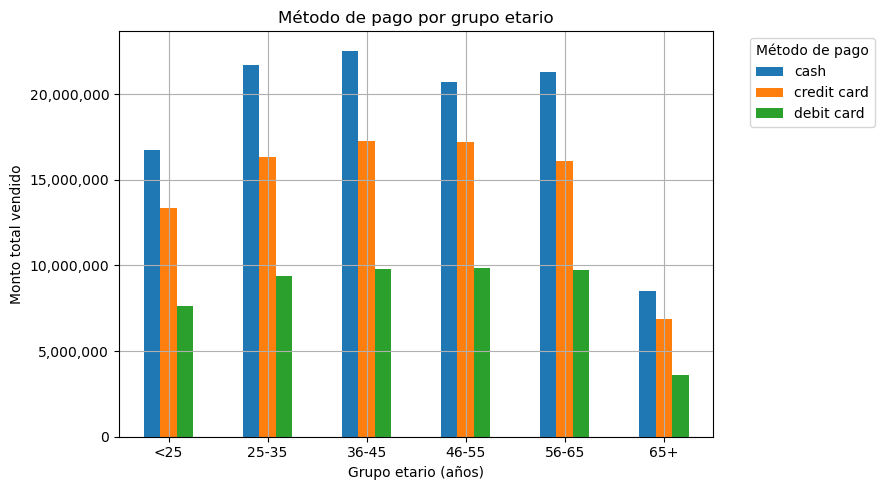

In [17]:
#  Método de pago por grupo etario

# 1️⃣ Creamos columna total_amount si no existe (price * quantity)
if "total_amount" not in clean_df.columns:
    clean_df["total_amount"] = clean_df["price"] * clean_df["quantity"]

# 2️⃣ Crear grupos etarios
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ["<25", "25-35", "36-45", "46-55", "56-65", "65+"]
clean_df["grupo_etario"] = pd.cut(clean_df["age"], bins=bins, labels=labels, right=True)

# 3️⃣ Agrupar por grupo etario y método de pago (sin warning)
ventas_pago_edad = (
    clean_df.groupby(["grupo_etario", "payment_method"], observed=True)["total_amount"]
    .sum()
    .reset_index()
    .sort_values("total_amount", ascending=False)
)

print("🧾 Ventas por método de pago y grupo etario:")
display(ventas_pago_edad.head(10))

# 4️⃣ Pivot table para graficar
pivot_pago_edad = ventas_pago_edad.pivot(
    index="grupo_etario", columns="payment_method", values="total_amount"
).fillna(0)

# 5️⃣ Gráfico agrupado
pivot_pago_edad.plot(kind="bar", figsize=(9,5))
plt.title("Método de pago por grupo etario")
plt.xlabel("Grupo etario (años)")
plt.ylabel("Monto total vendido")
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))  # ✅ miles sin notación científica
plt.xticks(rotation=0)
plt.legend(title="Método de pago", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



**Conclusiones y propuestas (Método de pago por grupo etario):**

*   **Conclusión:** El método de pago más utilizado en casi todos los grupos etarios es "cash" (efectivo), seguido por "credit card" y luego "debit card". El grupo etario 65+ muestra una menor preferencia por el efectivo en comparación con otros grupos.
*   **Propuestas:**
    *   **Incentivar métodos electrónicos:** Promover el uso de tarjetas de crédito y débito ofreciendo beneficios o descuentos exclusivos.
    *   **Facilitar pagos online:** Asegurar una experiencia de pago online sencilla y segura para todos los grupos etarios.
    *   **Analizar preferencias por grupo:** Realizar encuestas o estudios para entender mejor las preferencias de pago de cada grupo etario y adaptar las opciones disponibles.
    *   **Seguridad en efectivo:** Si el efectivo sigue siendo popular, asegurar medidas de seguridad adecuadas en los puntos de venta físicos.

🧾 Ventas totales por categoría:


,category,total_amount
1,Clothing,"112.711.848,48"
4,Shoes,"65.719.215,17"
6,Technology,"57.327.900,00"
2,Cosmetics,"6.709.794,52"
7,Toys,"3.947.489,28"
3,Food & Beverage,"840.387,78"
0,Books,"827.826,30"
5,Souvenir,"629.924,46"


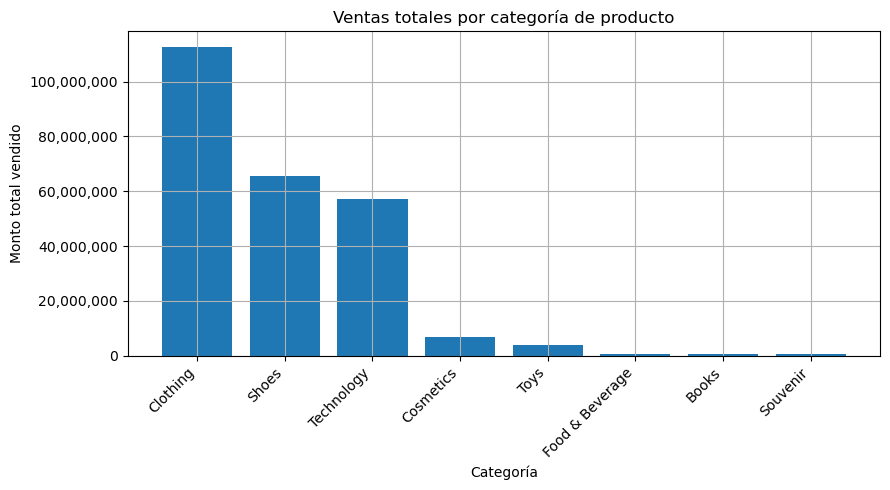

In [18]:
# Categoría por producto

# 1️⃣ Creamos columna total_amount si no existe (price * quantity)
if "total_amount" not in clean_df.columns:
    clean_df["total_amount"] = clean_df["price"] * clean_df["quantity"]

# Verificamos que existan columnas necesarias
cols_ok = {"category", "total_amount"}
if not cols_ok.issubset(clean_df.columns):
    print("❌ No se encontraron las columnas necesarias (category, total_amount).")
else:
    # 2️⃣ Agrupar por categoría y sumar ventas
    ventas_por_categoria = (
        clean_df.groupby("category")["total_amount"]
        .sum()
        .reset_index()
        .sort_values("total_amount", ascending=False)
    )

    print("🧾 Ventas totales por categoría:")
    display(ventas_por_categoria.head(10))

    # 3️⃣ Gráfico A: Monto total por categoría
    plt.figure(figsize=(9,5))
    plt.bar(ventas_por_categoria["category"], ventas_por_categoria["total_amount"])
    plt.title("Ventas totales por categoría de producto")
    plt.xlabel("Categoría")
    plt.ylabel("Monto total vendido")
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))  # ✅ eje Y sin notación científica
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Conclusiones y propuestas (Ventas por categoría):**

*   **Conclusión:** "Clothing", "Shoes" y "Technology" son claramente las categorías con mayor volumen de ventas. Las categorías "Food & Beverage", "Books" y "Souvenir" tienen una contribución mucho menor al total de ingresos.
*   **Propuestas:**
    *   **Enfoque en categorías top:** Continuar potenciando las categorías con mayor venta a través de promociones, variedad de productos y marketing.
    *   **Evaluar categorías de baja venta:** Analizar las categorías con menor venta para determinar si se deben mantener, reestructurar su oferta o considerar eliminarlas si no son rentables.
    *   **Estrategias de upselling/cross-selling:** Implementar estrategias para ofrecer productos de categorías complementarias (por ejemplo, accesorios al comprar ropa).

In [19]:
# EXPORTAR DATAFRAME LIMPIO EN CARPETA "OUTPUT"

import os
from datetime import datetime

# 1️⃣ Verificamos que exista clean_df
if 'clean_df' not in locals():
    print("❌ El DataFrame 'clean_df' no está en memoria. Ejecutá las celdas anteriores primero.")
else:
    # 2️⃣ Creamos carpeta 'output' si no existe
    os.makedirs("output", exist_ok=True)

    # 3️⃣ Generamos nombre con fecha/hora para versionar
    fecha_actual = datetime.now().strftime("%Y%m%d_%H%M%S")
    nombre_archivo = f"output/clean_sales_customers_{fecha_actual}.csv"

    # 4️⃣ Exportamos sin índice y con codificación UTF-8
    clean_df.to_csv(nombre_archivo, index=False, encoding="utf-8")

    print("✅ Archivo exportado correctamente.")
    print(f"📦 Ruta del archivo: {os.path.abspath(nombre_archivo)}")

    # 5️⃣ Mostramos primeras filas para verificación
    display(clean_df.head())

✅ Archivo exportado correctamente.
📦 Ruta del archivo: C:\Users\frans\Downloads\output\clean_sales_customers_20260413_113144.csv


,invoice_no,customer_id,category,quantity,price,invoice_date,shopping_mall,gender,age,payment_method,total_amount,grupo_etario,year_month
0,I138884,C241288,Clothing,5,"1.500,40",2022-08-05,Kanyon,female,28,credit card,"7.502,00",25-35,2022-08
1,I317333,C111565,Shoes,3,"1.800,51",2021-12-12,Forum Istanbul,male,21,debit card,"5.401,53",<25,2021-12
2,I127801,C266599,Clothing,1,"300,08",2021-11-09,Metrocity,male,20,cash,"300,08",<25,2021-11
3,I173702,C988172,Shoes,5,"3.000,85",2021-05-16,Metropol AVM,female,66,credit card,"15.004,25",65+,2021-05
4,I337046,C189076,Books,4,"60,60",2021-10-24,Kanyon,female,53,cash,"242,40",46-55,2021-10


## Conclusiones Generales

El análisis de ~98.000 transacciones de shopping malls en Turquía 
(2021–2023) permitió identificar los siguientes hallazgos principales:

- **Concentración de valor:** El 23.7% de los clientes genera el 80% 
  de las ventas totales, confirmando el principio de Pareto.
- **Comportamiento por género:** Las mujeres representan ~60% del 
  volumen de ventas, explicado por mayor frecuencia de compra y no 
  por ticket más alto.
- **Categorías líderes:** Clothing, Shoes y Technology concentran la 
  mayor parte de los ingresos en todos los shoppings analizados.
- **Distribución geográfica:** Mall of Istanbul y Kanyon suman más 
  del 40% de las ventas totales.
- **Método de pago:** El efectivo domina en todos los grupos etarios, 
  con menor preferencia en el segmento 65+.